In [12]:
import  pandas as pd

# Last ned datasettet
data = pd.read_csv('./agaricus-lepiota.csv', header=None)

# Legg til kolonnenavn
data.columns = ['edibility', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor', 'gill-attachment',
                'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root',
                'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring',
                'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type',
                'spore-print-color', 'population', 'habitat']

# Konverter kategoriske variabler til dummyvariabler
X = pd.get_dummies(data.drop('edibility', axis=1))
y = data['edibility'].apply(lambda x: 1 if x == 'p' else 0)  # 1 for giftig ('p'), 0 for spiselig ('e')

# Sjekk dataene
X.head()


,cap-shape_b,cap-shape_c,cap-shape_cap-shape,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_cap-surface,cap-surface_f,cap-surface_g,...,population_v,population_y,habitat_d,habitat_g,habitat_habitat,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,True,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

# Splitt dataene i trenings- og testsett
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Bruk RandomForest som klassifikator og utfør Recursive Feature Elimination (RFE)
clf = RandomForestClassifier()
rfe = RFE(clf, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Vis de viktigste features fra RFE
important_features = pd.Series(rfe.support_, index=X.columns)
important_features = important_features[important_features == True].index
print("Viktigste features (Feature Selection):", important_features)


Viktigste features (Feature Selection): Index(['odor_f', 'odor_n', 'gill-size_b', 'gill-size_n', 'gill-color_b',
       'stalk-shape_t', 'stalk-surface-above-ring_k',
       'stalk-surface-below-ring_k', 'ring-type_p', 'spore-print-color_h'],
      dtype='object')


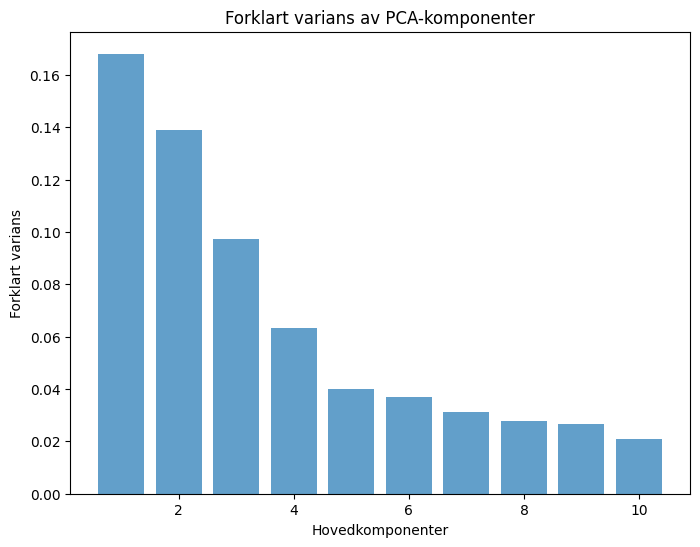

Viktigste features fra PCA (Første komponent):
ring-type_p                   0.294732
bruises?_t                    0.280694
odor_n                        0.207015
gill-size_b                   0.202084
stalk-surface-above-ring_s    0.200547
stalk-surface-below-ring_s    0.185700
spore-print-color_n           0.145479
spore-print-color_k           0.140684
stalk-root_b                  0.117521
stalk-color-below-ring_w      0.100784
Name: 0, dtype: float64


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Utfør PCA på dataene
pca = PCA(n_components=10)  #Reduser dimensjonene i dataene til 10 komponenter som forklarer mest varians
pca.fit(X)

# Forklaringsgrad for hver komponent
explained_variance = pca.explained_variance_ratio_

# Plott forklaringsgraden
plt.figure(figsize=(8,6))
plt.bar(range(1, 11), explained_variance, alpha=0.7, align='center', label='Explained variance')
plt.xlabel('Hovedkomponenter')
plt.ylabel('Forklart varians')
plt.title('Forklart varians av PCA-komponenter')
plt.show()

# Se hvilke features som har størst vekter i den første komponenten
pca_components = pd.DataFrame(pca.components_, columns=X.columns)
print("Viktigste features fra PCA (Første komponent):")
print(pca_components.iloc[0].nlargest(10))  # De 10 viktigste features fra første komponent


In [10]:
# Se hvilke features som overlapper mellom RFE og PCA
overlapping_features = set(important_features).intersection(set(pca_components.iloc[0].nlargest(10).index))
print("Overlappende features mellom PCA og Feature Selection:", overlapping_features)


Overlappende features mellom PCA og Feature Selection: {'odor_n', 'ring-type_p', 'gill-size_b'}
